In [ ]:
# # Importing python libraries 

# import pandas as pd
# from pathlib import Path 

# # root data directory 
# data_dir = Path(r'C:/Users/acer/OneDrive/Desktop/NPL-Auction-System-/data/nepal_premeire_league_2024')

# #directory to store DataFrames
# all_dfs = []

# # recursively read all csv files 
# for csv_file in data_dir.rglob("*.csv"):
#     df = pd.read_csv(csv_file)
#     df["category"]= csv_file.parent.name 
#     df["source_file"] = csv_file.name 
#     all_dfs.append(df)

# final_df = pd.concat(all_dfs, ignore_index=True)




In [1]:
# final_df.describe()

In [2]:
# final_df.shape

In [3]:
# final_df.size

In [4]:
# final_df.head()

In [6]:
# final_df.isnull()

In [7]:
# final_df.isnull().sum()

In [8]:
# batting_df = final_df[final_df["category"]== "Batting Records"].copy()
# bowling_df = final_df[final_df["category"]== "Bowling Records"].copy()
# fielding_df = final_df[final_df["category"]== "Feilding Records"].copy()
# wicketkeeping_df = final_df[final_df['category']== "WicketKeepingRecords"].copy

In [9]:
# import pandas as pd

# bat_path = data_dir / "Batting Records" / "most_runs.csv"
# bat = pd.read_csv(bat_path)

In [10]:
# bat = bat[[
#     "Player",
#     "matches_played",
#     "innings_batted",
#     "runs_scored",
#     "batting_average",
#     "balls_faced",
#     "batting_strike_rate"
# ]]

# final_df.columns

# Cleaning Data Separately

In [12]:
# Data for Batting 

import pandas as pd
bat = pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\NPL-Auction-System-\data\nepal_premeire_league_2024\Batting Records\most_runs.csv")


In [13]:
bat.head(5)

,player,span,matches_played,innings_batted,not_out,runs,highest_inns_score,batting_average,balls_faced,strike_rate,hundreds_scored,fifties_scored,ducks_scored,boundary_fours,boundary_sixes
0,BKEL Milantha (JAB),2024-2024,10,10,1,293,87,32.55,224,130.80,-,2,-,35,9
1,RS Bopara (CHR),2024-2024,8,8,1,286,59*,40.85,211,135.54,-,3,-,24,11
2,RK Paudel (LUL),2024-2024,7,7,-,279,95,39.85,212,131.60,-,2,-,26,11
3,SA Zaib (SPR),2024-2024,9,9,-,275,90,30.55,202,136.13,-,2,-,24,12
4,JDS Neesham (JAB),2024-2024,9,9,2,247,65,35.28,126,196.03,-,1,-,14,23


In [14]:
##step1: Standarize column Names 

##convert column names to lowercase and remove extra spaces 
##ensure consistent column naming and avoid errors

bat.columns = bat.columns.str.strip().str.lower()


In [15]:
# step2:  clean player names 

bat['Player'] = bat['player'].str.replace(r"\(.*\)", "", regex = True)

In [16]:
#step3: replace '_' with 0

bat = bat.replace('_', 0)

In [17]:
#step4: clean highest innings score (remove *)
# Removing * from the column highest_inns_score

bat['highest_inns_score'] = (
    bat['highest_inns_score'].astype(str)
    .str.replace("*", "", regex=False))

#convert the cleaned column to numeric values 
bat['highest_inns_score'] = pd.to_numeric(
    bat['highest_inns_score'],
      errors = 'coerce')

In [18]:
#step5: convert numeric columns 
numeric_cols = [
    "matches_played", "innings_batted", "not_out", "runs", "highest_inns_score",
    "batting_average","balls_faced","strike_rate",
    "hundreds_scored","fifties_scored","ducks_scored","boundary_fours",
    "boundary_sixes"
]

bat[numeric_cols] = bat[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [19]:
#step6: remove unnecessary columns 
#drop 'span' column
bat = bat.drop(columns=["span"], errors='ignore')

In [20]:
#step7: handle missing values 
bat = bat.fillna(0)

In [21]:
#removing duplicates
bat = bat.drop_duplicates(subset="player")

In [22]:
# inspecting data
bat.head()

,player,matches_played,innings_batted,not_out,runs,highest_inns_score,batting_average,balls_faced,strike_rate,hundreds_scored,fifties_scored,ducks_scored,boundary_fours,boundary_sixes,Player
0,BKEL Milantha (JAB),10,10,1.0,293.0,87.0,32.55,224,130.80,0.0,2.0,0.0,35,9,BKEL Milantha
1,RS Bopara (CHR),8,8,1.0,286.0,59.0,40.85,211,135.54,0.0,3.0,0.0,24,11,RS Bopara
2,RK Paudel (LUL),7,7,0.0,279.0,95.0,39.85,212,131.60,0.0,2.0,0.0,26,11,RK Paudel
3,SA Zaib (SPR),9,9,0.0,275.0,90.0,30.55,202,136.13,0.0,2.0,0.0,24,12,SA Zaib
4,JDS Neesham (JAB),9,9,2.0,247.0,65.0,35.28,126,196.03,0.0,1.0,0.0,14,23,JDS Neesham


In [23]:
bat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player              120 non-null    object 
 1   matches_played      120 non-null    int64  
 2   innings_batted      120 non-null    int64  
 3   not_out             120 non-null    float64
 4   runs                120 non-null    float64
 5   highest_inns_score  120 non-null    float64
 6   batting_average     120 non-null    float64
 7   balls_faced         120 non-null    int64  
 8   strike_rate         120 non-null    float64
 9   hundreds_scored     120 non-null    float64
 10  fifties_scored      120 non-null    float64
 11  ducks_scored        120 non-null    float64
 12  boundary_fours      120 non-null    int64  
 13  boundary_sixes      120 non-null    int64  
 14  Player              120 non-null    object 
dtypes: float64(8), int64(5), object(2)
memory usage: 14.2+ KB

In [24]:
bat.describe()

,matches_played,innings_batted,not_out,runs,highest_inns_score,batting_average,balls_faced,strike_rate,hundreds_scored,fifties_scored,ducks_scored,boundary_fours,boundary_sixes
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,5.791667,4.666667,0.875000,67.808333,26.791667,13.589250,60.291667,92.348583,0.008333,0.233333,0.500000,5.441667,2.841667
std,2.706655,2.580904,1.025412,74.188868,24.260109,11.595514,56.776045,41.343622,0.091287,0.545930,0.721809,6.863367,3.974701
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2.000000,0.000000,12.000000,8.000000,4.957500,16.000000,66.660000,0.000000,0.000000,0.000000,0.750000,0.000000
50%,6.000000,5.000000,1.000000,41.500000,17.000000,12.000000,39.500000,96.475000,0.000000,0.000000,0.000000,2.500000,1.000000
75%,8.000000,7.000000,1.000000,103.500000,40.250000,19.125000,96.000000,122.295000,0.000000,0.000000,1.000000,8.000000,4.250000
max,10.000000,10.000000,4.000000,293.000000,104.000000,50.000000,224.000000,196.030000,1.000000,3.000000,3.000000,35.000000,23.000000


# Cleaning data of bowling

In [25]:
# importing data for bowling 
import pandas as pd 
bowl = pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\NPL-Auction-System-\data\nepal_premeire_league_2024\Bowling Records\most_wickets.csv")


In [26]:
bowl.head()

,player,span,matches_played,innings_bowled,balls,overs,maidens_earned,conceded,wicket,best_innings_bowling,bowling_average,economy_rate,strike_rate,four_wickets,five_wickets
0,SC Kuggeleijn (SPR),2024-2024,9,9,173,28.5,1,210,17,5/18,12.35,7.28,10.17,-,1
1,LN Rajbanshi (JAB),2024-2024,10,10,240,40.0,5,213,17,3/8,12.52,5.32,14.11,-,-
2,Sohail Tanvir (CHR),2024-2024,8,8,182,30.2,1,174,14,5/21,12.42,5.73,13.00,-,1
3,K Mahato (JAB),2024-2024,10,10,198,33.0,1,265,14,4/35,18.92,8.03,14.14,1,-
4,BP Sharma (KAY),2024-2024,8,8,174,29.0,2,171,13,3/17,13.15,5.89,13.38,-,-


In [27]:
bowl.dtypes

player                   object
span                     object
matches_played            int64
innings_bowled            int64
balls                     int64
overs                   float64
maidens_earned           object
conceded                  int64
wicket                    int64
best_innings_bowling     object
bowling_average         float64
economy_rate            float64
strike_rate             float64
four_wickets             object
five_wickets             object
dtype: object

In [28]:
# standarizing column names 
bowl.columns = bowl.columns.str.strip().str.lower()

# clean player names 
bowl["player"] = bowl["player"].str.replace(r"\(.*\)", "", regex= True)


# Replace '_ ' with 0
bowl = bowl.replace("_",0)

# splitting best bowling figures   (5/21)
bowl[['best_wickets', 'best_runs']] = bowl["best_innings_bowling"].str.split("/", expand=True)
# converting the split columns into numeric format 
bowl["best_wickets"] = pd.to_numeric(bowl["best_wickets"], errors="coerce")
bowl["best_runs"]= pd.to_numeric(bowl["best_runs"], errors='coerce')


# converting numeric columns 
numeric_cols = [
    "matches_played",
    "innings_bowled",
    "balls",
    "overs",
    "maidens_earned",
    "conceded",
    "wicket",
    "bowling_average",
    "economy_rate",
    "strike_rate",
    "four_wickets",
    "five_wickets"
]

bowl[numeric_cols] = bowl[numeric_cols].apply(pd.to_numeric, errors="coerce")


# removing unnecessary columns 
bowl = bowl.drop(columns=["span"], errors='ignore')

# handling missing data (replacing missing value with 0)
bowl = bowl.fillna(0)

# removing duplicates 
bowl = bowl.drop_duplicates(subset="player")



In [29]:
# inspecting data 
bowl.head()

,player,matches_played,innings_bowled,balls,overs,maidens_earned,conceded,wicket,best_innings_bowling,bowling_average,economy_rate,strike_rate,four_wickets,five_wickets,best_wickets,best_runs
0,SC Kuggeleijn,9,9,173,28.5,1.0,210,17,5/18,12.35,7.28,10.17,0.0,1.0,5,18
1,LN Rajbanshi,10,10,240,40.0,5.0,213,17,3/8,12.52,5.32,14.11,0.0,0.0,3,8
2,Sohail Tanvir,8,8,182,30.2,1.0,174,14,5/21,12.42,5.73,13.00,0.0,1.0,5,21
3,K Mahato,10,10,198,33.0,1.0,265,14,4/35,18.92,8.03,14.14,1.0,0.0,4,35
4,BP Sharma,8,8,174,29.0,2.0,171,13,3/17,13.15,5.89,13.38,0.0,0.0,3,17


In [30]:
bowl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   player                71 non-null     object 
 1   matches_played        71 non-null     int64  
 2   innings_bowled        71 non-null     int64  
 3   balls                 71 non-null     int64  
 4   overs                 71 non-null     float64
 5   maidens_earned        71 non-null     float64
 6   conceded              71 non-null     int64  
 7   wicket                71 non-null     int64  
 8   best_innings_bowling  71 non-null     object 
 9   bowling_average       71 non-null     float64
 10  economy_rate          71 non-null     float64
 11  strike_rate           71 non-null     float64
 12  four_wickets          71 non-null     float64
 13  five_wickets          71 non-null     float64
 14  best_wickets          71 non-null     int64  
 15  best_runs             71 

In [31]:
bowl.describe()

,matches_played,innings_bowled,balls,overs,maidens_earned,conceded,wicket,bowling_average,economy_rate,strike_rate,four_wickets,five_wickets,best_wickets,best_runs
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,6.295775,5.338028,98.521127,16.364789,0.366197,115.211268,5.802817,26.815775,7.464648,20.983239,0.070423,0.070423,2.352113,20.704225
std,2.457608,2.682982,60.612790,10.080534,0.797128,66.787919,4.347806,19.955039,1.649602,13.438856,0.308172,0.257679,1.231707,8.276290
min,1.000000,1.000000,6.000000,1.000000,0.000000,8.000000,1.000000,4.660000,4.500000,4.000000,0.000000,0.000000,1.000000,6.000000
25%,5.000000,3.000000,45.000000,7.500000,0.000000,57.000000,2.000000,14.440000,6.490000,13.440000,0.000000,0.000000,1.000000,16.000000
50%,7.000000,6.000000,96.000000,16.000000,0.000000,120.000000,5.000000,20.500000,7.310000,16.800000,0.000000,0.000000,2.000000,20.000000
75%,8.000000,7.000000,148.000000,24.600000,0.500000,171.000000,9.000000,31.415000,8.035000,22.640000,0.000000,0.000000,3.000000,26.000000
max,10.000000,10.000000,240.000000,40.000000,5.000000,265.000000,17.000000,111.000000,12.850000,89.000000,2.000000,1.000000,6.000000,43.000000


## cleaning data of fielding


In [32]:
# importing data of fielding 
import pandas as pd 

# load the dataset from csv
field = pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\NPL-Auction-System-\data\nepal_premeire_league_2024\Fielding Records\most_catches.csv")

In [33]:
field.head()

,player,Span,matches_played,innings,catches,Maximum_innings_catches,Catches_per_innings
0,AK Sah (JAB),2024-2024,7,7,12,5,1.714
1,B McMullen (SPR),2024-2024,9,9,10,2,1.111
2,NB Budayair (SPR),2024-2024,9,9,9,3,1
3,Saad Bin Zafar (LUL),2024-2024,7,7,6,2,0.857
4,Gulsan Jha (KAY),2024-2024,9,9,6,4,0.666


In [34]:
# standarizing the columns 
field.columns = field.columns.str.strip().str.lower()

# removing the team abbreviations from player names 
field["player"] = field['player'].str.replace(r"\(.*\)", "", regex=True)

# replacing value '_' to 0
field = field.replace("_", 0)

# converting numeric columns 
numeric_cols = ["matches_played","innings","catches",
                "maximum_innings_catches","catches_per_innings"]

field[numeric_cols] = field[numeric_cols].apply(pd.to_numeric, errors="coerce")


In [35]:
# removing unnecessary columns 
field = field.drop(columns=["span"], errors="coerce")

In [36]:
# handling missing data 
field = field.fillna(0)

In [37]:
# removing duplicates 
field = field.drop_duplicates(subset="player")


In [38]:
# insighting data 
field.head()

,player,matches_played,innings,catches,maximum_innings_catches,catches_per_innings
0,AK Sah,7,7.0,12.0,5.0,1.714
1,B McMullen,9,9.0,10.0,2.0,1.111
2,NB Budayair,9,9.0,9.0,3.0,1.000
3,Saad Bin Zafar,7,7.0,6.0,2.0,0.857
4,Gulsan Jha,9,9.0,6.0,4.0,0.666


In [39]:
field.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player                   100 non-null    object 
 1   matches_played           100 non-null    int64  
 2   innings                  100 non-null    float64
 3   catches                  100 non-null    float64
 4   maximum_innings_catches  100 non-null    float64
 5   catches_per_innings      100 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [40]:
field.describe()

,matches_played,innings,catches,maximum_innings_catches,catches_per_innings
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,5.780000,5.240000,2.090000,1.150000,0.357480
std,2.809004,3.078502,2.127715,0.936089,0.403161
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2.000000,1.000000,1.000000,0.125000
50%,7.000000,6.000000,2.000000,1.000000,0.285000
75%,8.000000,8.000000,3.000000,2.000000,0.500000
max,10.000000,10.000000,12.000000,5.000000,3.000000


## cleaning data of wicketkeeping 


In [41]:
# importing data of wicket keeping 
import pandas as pd 
wk = pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\NPL-Auction-System-\data\nepal_premeire_league_2024\WicketKeepingRecords\most_dismissals.csv")

wk.head()

,player,span,matches_played,innings_as_keeper,dismissed,Caught_as_a_keeper,stumpings,maximum_dismissals_per_innings,dismissials_per_innings
0,BKEL Milantha (JAB),2024-2024,10,8,5,1,4,2 (1ct 1st),0.625
1,B Rawal (CHR),2024-2024,8,8,5,5,-,1 (1ct 0st),0.625
2,A Saud (LUL),2024-2024,6,6,4,1,3,2 (0ct 2st),0.666
3,B Bhandari (SPR),2024-2024,9,9,4,1,3,2 (1ct 1st),0.444
4,CAK Walton (KAY),2024-2024,9,9,4,4,-,1 (1ct 0st),0.444


In [42]:
wk.columns

Index(['player', 'span', 'matches_played', 'innings_as_keeper', 'dismissed',
       'Caught_as_a_keeper', 'stumpings', 'maximum_dismissals_per_innings',
       'dismissials_per_innings'],
      dtype='object')

In [43]:
# standarizing columns names 
wk.columns = wk.columns.str.strip().str.lower()

# clean player names 
wk["player"] = wk["player"].str.replace(r"\(.*\)", "", regex=True)

# replacing '_' with 0
wk = wk.replace("_", 0)

# Extracting numeric value from 'maximum_dismissals_per_innings'

wk["maximum_dismissals_per_innings"] = (
    wk["maximum_dismissals_per_innings"]
    .astype(str)
    .str.extract(r'(\d+)')
)

wk["maximum_dismissals_per_innings"] = pd.to_numeric(
    wk["maximum_dismissals_per_innings"],
    errors="coerce"
)


# converting numeric columns 
numeric_cols = [
    "matches_played",
    "innings_as_keeper",
    "dismissed",
    "caught_as_a_keeper",
    "stumpings",
    "maximum_dismissals_per_innings",
    "dismissials_per_innings"
]

wk[numeric_cols] = wk[numeric_cols].apply(pd.to_numeric, errors="coerce")

# removing unnecessary columns 
wk = wk.drop(columns=["span"], errors="ignore")

# handling missing data 
wk = wk.fillna(0)

# removing duplicate players 
wk = wk.drop_duplicates(subset='player')


In [44]:
wk.head()


,player,matches_played,innings_as_keeper,dismissed,caught_as_a_keeper,stumpings,maximum_dismissals_per_innings,dismissials_per_innings
0,BKEL Milantha,10,8,5.0,1.0,4.0,2.0,0.625
1,B Rawal,8,8,5.0,5.0,0.0,1.0,0.625
2,A Saud,6,6,4.0,1.0,3.0,2.0,0.666
3,B Bhandari,9,9,4.0,1.0,3.0,2.0,0.444
4,CAK Walton,9,9,4.0,4.0,0.0,1.0,0.444


In [45]:
wk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   player                          13 non-null     object 
 1   matches_played                  13 non-null     int64  
 2   innings_as_keeper               13 non-null     int64  
 3   dismissed                       13 non-null     float64
 4   caught_as_a_keeper              13 non-null     float64
 5   stumpings                       13 non-null     float64
 6   maximum_dismissals_per_innings  13 non-null     float64
 7   dismissials_per_innings         13 non-null     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 964.0+ bytes


In [46]:
wk.describe()

,matches_played,innings_as_keeper,dismissed,caught_as_a_keeper,stumpings,maximum_dismissals_per_innings,dismissials_per_innings
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,6.615385,4.923077,2.538462,1.461538,1.076923,1.307692,0.447692
std,2.724532,2.985005,1.853617,1.506397,1.497862,0.947331,0.306807
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.250000
50%,7.000000,5.000000,3.000000,1.000000,0.000000,1.000000,0.500000
75%,9.000000,8.000000,4.000000,2.000000,2.000000,2.000000,0.625000
max,10.000000,9.000000,5.000000,5.000000,4.000000,3.000000,1.000000


# Merging all the data and saving it as npl_data


In [47]:
# ------------------------------------------------------------
# FINAL CODE: MERGE ALL DATASETS AND SAVE FINAL DATASET
# ------------------------------------------------------------

import pandas as pd

# Step 1: Rename duplicate columns to avoid merge conflicts
# Each dataset may contain 'matches_played', so we rename them

bat = bat.rename(columns={"matches_played": "bat_matches"})
bowl = bowl.rename(columns={"matches_played": "bowl_matches"})
field = field.rename(columns={"matches_played": "field_matches"})
wk = wk.rename(columns={"matches_played": "wk_matches"})


# Step 2: Merge batting and bowling datasets
# 'outer' merge keeps all players from both datasets
npl_data = bat.merge(bowl, on="player", how="outer")


# Step 3: Merge fielding dataset
npl_data = npl_data.merge(field, on="player", how="outer")


# Step 4: Merge wicketkeeping dataset
npl_data = npl_data.merge(wk, on="player", how="outer")


# Step 5: Replace missing values with 0
# Some players may not have bowling or wicketkeeping stats
npl_data = npl_data.fillna(0)


# Step 6: Check the merged dataset
print(npl_data.head())
print(npl_data.info())


# Step 7: Save the final dataset
npl_data.to_csv("npl_data.csv", index=False)

print("Final dataset saved successfully as 'npl_data.csv'")

           player  bat_matches  innings_batted  not_out  runs  \
0       A Bohara           0.0             0.0      0.0   0.0   
1  A Bohara (SPR)          9.0             2.0      2.0   2.0   
2       A Gharti           0.0             0.0      0.0   0.0   
3  A Gharti (KAY)          9.0             7.0      1.0  79.0   
4     A Ghiraiya           0.0             0.0      0.0   0.0   

   highest_inns_score  batting_average  balls_faced  strike_rate_x  \
0                 0.0             0.00          0.0           0.00   
1                 2.0             0.00          3.0          66.66   
2                 0.0             0.00          0.0           0.00   
3                33.0            13.16         72.0         109.72   
4                 0.0             0.00          0.0           0.00   

   hundreds_scored  ...  catches  maximum_innings_catches  \
0              0.0  ...      2.0                      1.0   
1              0.0  ...      0.0                      0.0   
2    

In [48]:
# importing libraries
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [49]:
df = pd.read_csv("npl_data.csv")

In [50]:
df.head()

,player,bat_matches,innings_batted,not_out,runs,highest_inns_score,batting_average,balls_faced,strike_rate_x,hundreds_scored,...,catches,maximum_innings_catches,catches_per_innings,wk_matches,innings_as_keeper,dismissed,caught_as_a_keeper,stumpings,maximum_dismissals_per_innings,dismissials_per_innings
0,A Bohara,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,2.0,1.0,0.222,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A Bohara (SPR),9.0,2.0,2.0,2.0,2.0,0.00,3.0,66.66,0.0,...,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A Gharti,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,2.0,1.0,0.222,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A Gharti (KAY),9.0,7.0,1.0,79.0,33.0,13.16,72.0,109.72,0.0,...,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A Ghiraiya,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,...,1.0,1.0,0.166,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   player                          232 non-null    object 
 1   bat_matches                     232 non-null    float64
 2   innings_batted                  232 non-null    float64
 3   not_out                         232 non-null    float64
 4   runs                            232 non-null    float64
 5   highest_inns_score              232 non-null    float64
 6   batting_average                 232 non-null    float64
 7   balls_faced                     232 non-null    float64
 8   strike_rate_x                   232 non-null    float64
 9   hundreds_scored                 232 non-null    float64
 10  fifties_scored                  232 non-null    float64
 11  ducks_scored                    232 non-null    float64
 12  boundary_fours                  232 

In [52]:
df.describe()

,bat_matches,innings_batted,not_out,runs,highest_inns_score,batting_average,balls_faced,strike_rate_x,hundreds_scored,fifties_scored,...,catches,maximum_innings_catches,catches_per_innings,wk_matches,innings_as_keeper,dismissed,caught_as_a_keeper,stumpings,maximum_dismissals_per_innings,dismissials_per_innings
count,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,...,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000
mean,2.995690,2.413793,0.452586,35.073276,13.857759,7.028922,31.185345,47.766509,0.004310,0.120690,...,0.900862,0.495690,0.154086,0.370690,0.275862,0.142241,0.081897,0.060345,0.073276,0.025086
std,3.490864,2.982108,0.856547,63.154444,21.981920,10.750667,50.717067,54.948110,0.065653,0.408888,...,1.736693,0.837425,0.318018,1.646353,1.323031,0.721668,0.480998,0.422091,0.370762,0.124649
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.000000,5.000000,1.000000,42.500000,20.000000,12.165000,43.500000,97.967500,0.000000,0.000000,...,1.000000,1.000000,0.229000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,4.000000,293.000000,104.000000,50.000000,224.000000,196.030000,1.000000,3.000000,...,12.000000,5.000000,3.000000,10.000000,9.000000,5.000000,5.000000,4.000000,3.000000,1.000000


In [53]:
df.columns

Index(['player', 'bat_matches', 'innings_batted', 'not_out', 'runs',
       'highest_inns_score', 'batting_average', 'balls_faced', 'strike_rate_x',
       'hundreds_scored', 'fifties_scored', 'ducks_scored', 'boundary_fours',
       'boundary_sixes', 'Player', 'bowl_matches', 'innings_bowled', 'balls',
       'overs', 'maidens_earned', 'conceded', 'wicket', 'best_innings_bowling',
       'bowling_average', 'economy_rate', 'strike_rate_y', 'four_wickets',
       'five_wickets', 'best_wickets', 'best_runs', 'field_matches', 'innings',
       'catches', 'maximum_innings_catches', 'catches_per_innings',
       'wk_matches', 'innings_as_keeper', 'dismissed', 'caught_as_a_keeper',
       'stumpings', 'maximum_dismissals_per_innings',
       'dismissials_per_innings'],
      dtype='object')

In [54]:
df.size

9744

In [55]:
df.shape

(232, 42)

In [56]:
# removing duplicates (strike_rate )

df = df.rename(columns={
    "strike_rate_x": "batting_strike_rate",
    "strike_rate_y": "bowling_strike_rate"
})

In [57]:
df.columns

Index(['player', 'bat_matches', 'innings_batted', 'not_out', 'runs',
       'highest_inns_score', 'batting_average', 'balls_faced',
       'batting_strike_rate', 'hundreds_scored', 'fifties_scored',
       'ducks_scored', 'boundary_fours', 'boundary_sixes', 'Player',
       'bowl_matches', 'innings_bowled', 'balls', 'overs', 'maidens_earned',
       'conceded', 'wicket', 'best_innings_bowling', 'bowling_average',
       'economy_rate', 'bowling_strike_rate', 'four_wickets', 'five_wickets',
       'best_wickets', 'best_runs', 'field_matches', 'innings', 'catches',
       'maximum_innings_catches', 'catches_per_innings', 'wk_matches',
       'innings_as_keeper', 'dismissed', 'caught_as_a_keeper', 'stumpings',
       'maximum_dismissals_per_innings', 'dismissials_per_innings'],
      dtype='object')

In [58]:
# checking missing values 
df.isnull().sum()

player                            0
bat_matches                       0
innings_batted                    0
not_out                           0
runs                              0
highest_inns_score                0
batting_average                   0
balls_faced                       0
batting_strike_rate               0
hundreds_scored                   0
fifties_scored                    0
ducks_scored                      0
boundary_fours                    0
boundary_sixes                    0
Player                            0
bowl_matches                      0
innings_bowled                    0
balls                             0
overs                             0
maidens_earned                    0
conceded                          0
wicket                            0
best_innings_bowling              0
bowling_average                   0
economy_rate                      0
bowling_strike_rate               0
four_wickets                      0
five_wickets                

In [59]:
# remove duplicate column 

df = df.drop(columns=["Player"], errors = "ignore")


#  drop non - numeric column
df = df.drop(columns=["best_innings_bowling"], errors = "ignore")

# 

In [60]:
df.fillna(0, inplace=True)

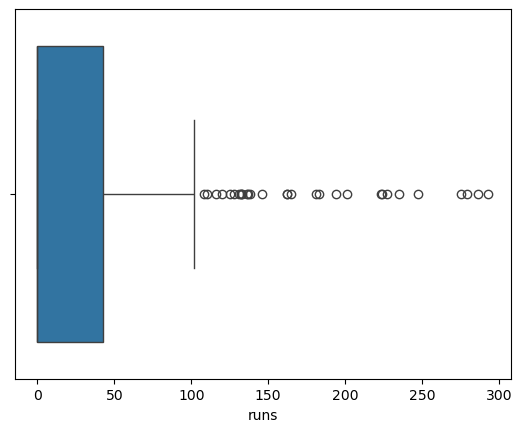

In [61]:
#  checking extreme outliers 
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.boxplot(x=df["runs"])
plt.show()

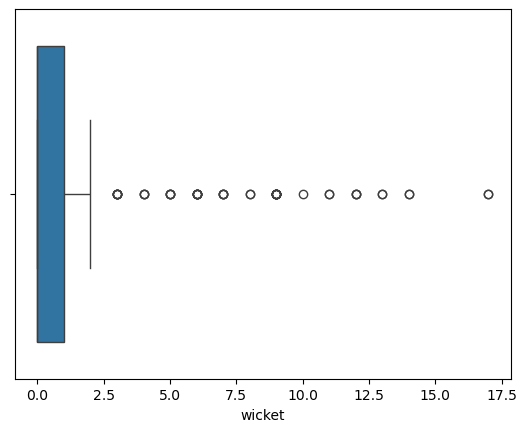

In [62]:
# for wickets
sns.boxplot(x=df["wicket"])
plt.show()

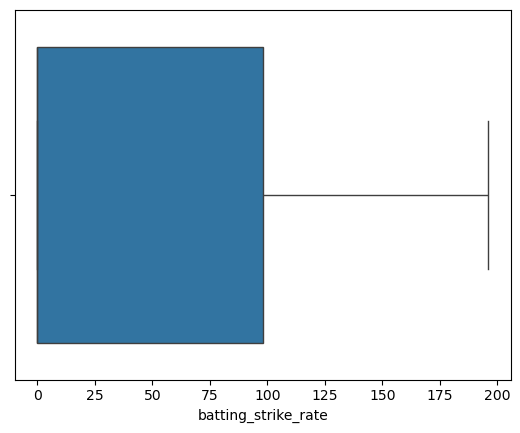

In [63]:
# for strike rates
sns.boxplot(x=df["batting_strike_rate"])
plt.show()

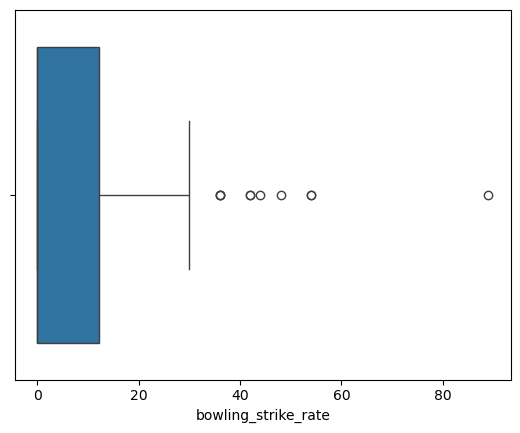

In [64]:
sns.boxplot(x=df["bowling_strike_rate"])
plt.show()

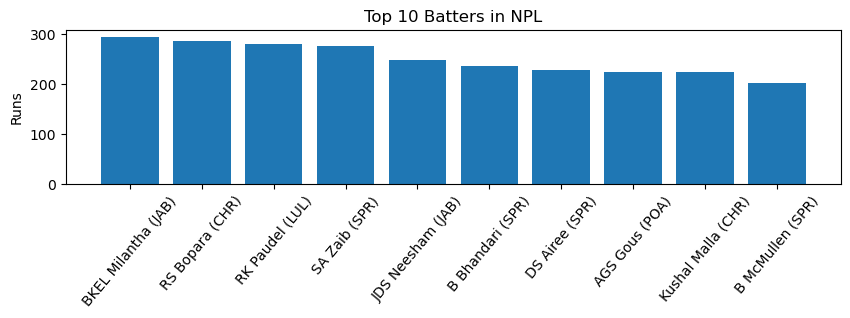

In [65]:
# top 10 batters (by runs )
top_batters = df.sort_values("runs", ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
plt.bar(top_batters["player"], top_batters["runs"])
plt.xticks(rotation=50)
plt.title("Top 10 Batters in NPL")
plt.ylabel("Runs")
plt.show()

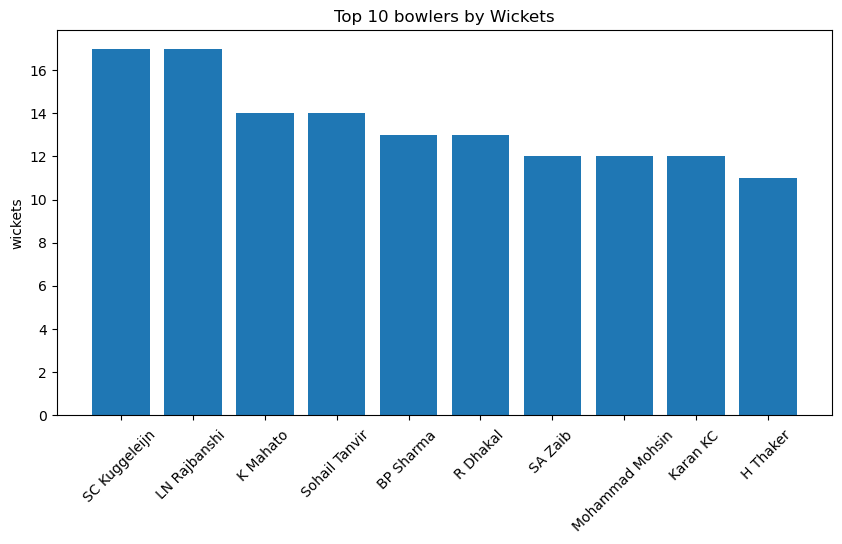

In [66]:
# Top 10 Bowlers (By wickets)

top_bowlers = df.sort_values("wicket", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_bowlers["player"], top_bowlers["wicket"])
plt.xticks(rotation=45)
plt.title("Top 10 bowlers by Wickets")
plt.ylabel("wickets")
plt.show()

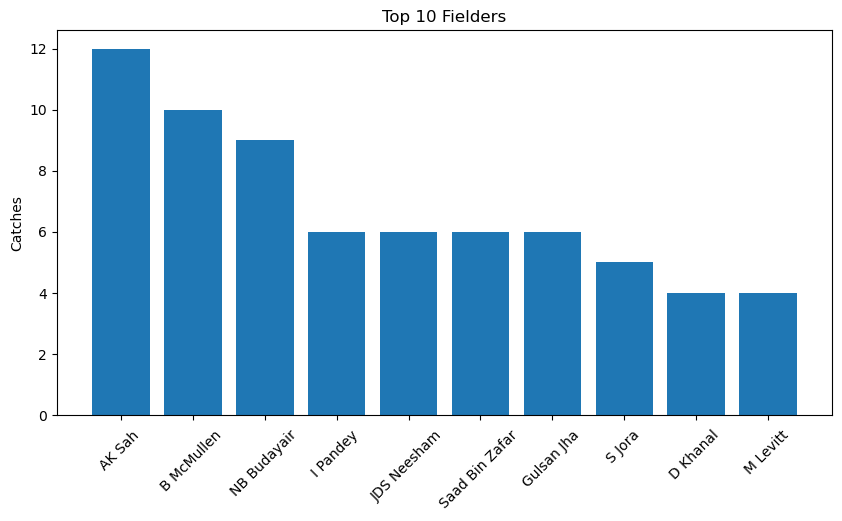

In [67]:
# Top 10 Fielders (By Catches)
top_fielders = df.sort_values("catches", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_fielders["player"], top_fielders["catches"])
plt.xticks(rotation=45)
plt.title("Top 10 Fielders")
plt.ylabel("Catches")
plt.show()

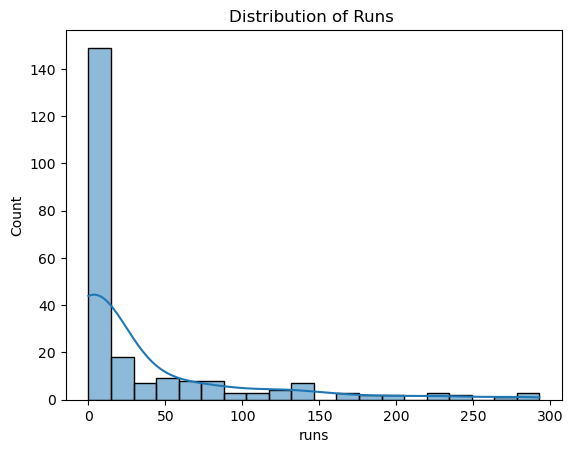

In [68]:
# Distribution of Runs 
import seaborn as sns 

sns.histplot(df["runs"], bins=20, kde=True)
plt.title("Distribution of Runs ")
plt.show()

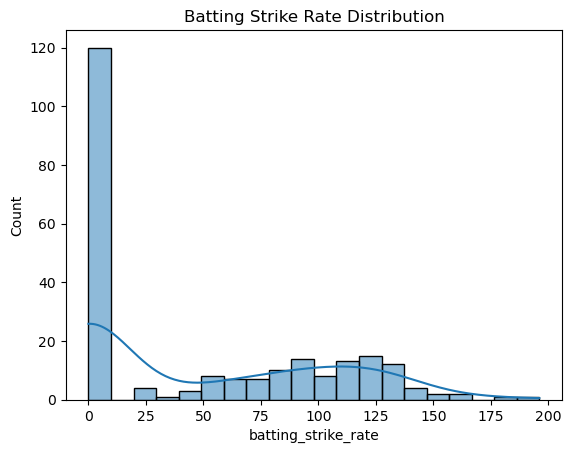

In [69]:
# Batting Strike Rate Distribution 

sns.histplot(df["batting_strike_rate"], bins=20, kde=True)
plt.title("Batting Strike Rate Distribution")
plt.show()

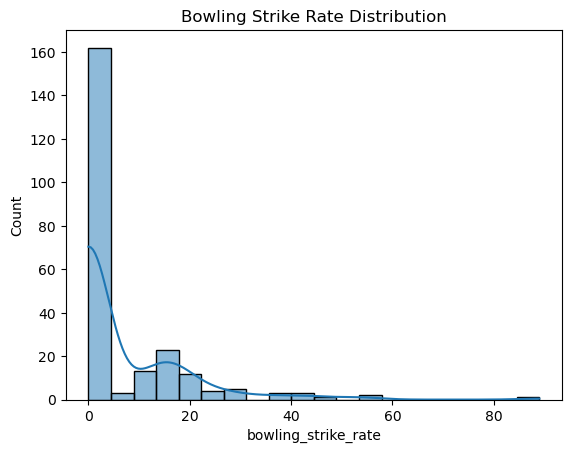

In [70]:
# Bowling Strike Rate Distribution 

sns.histplot(df["bowling_strike_rate"], bins=20, kde=True)
plt.title("Bowling Strike Rate Distribution")
plt.show()

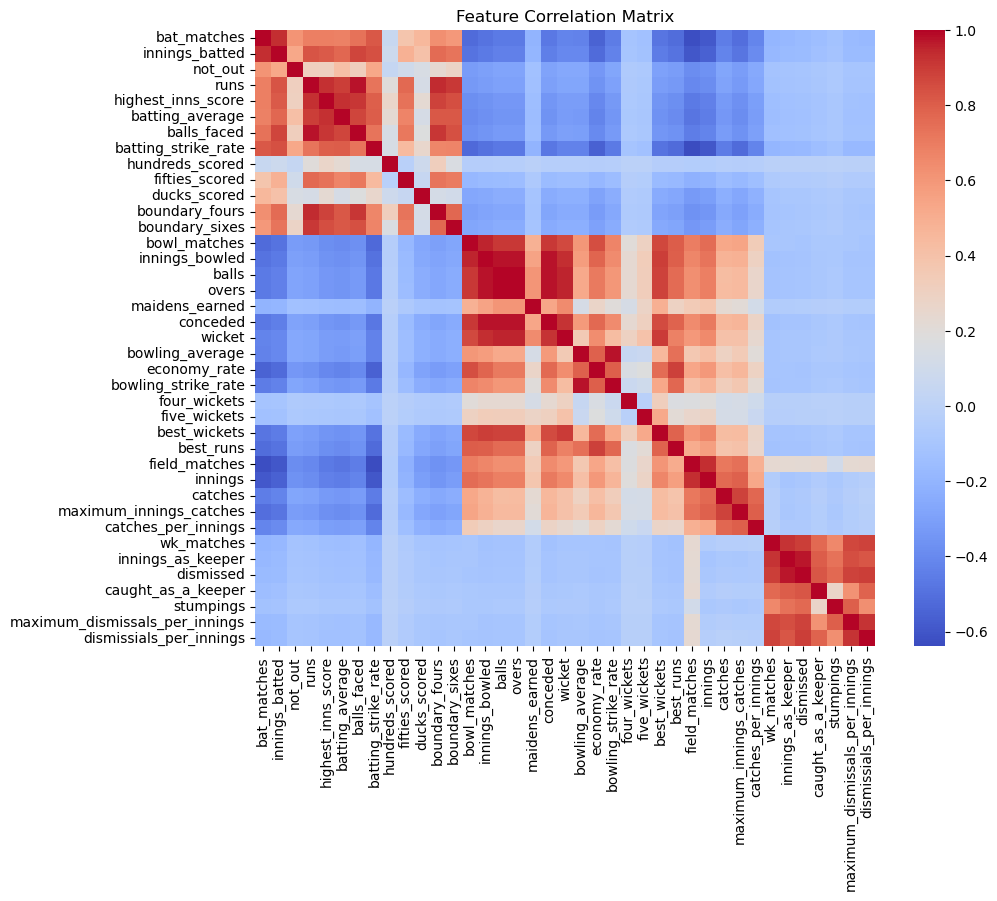

In [71]:
# Featuring Correlation Heatmap 

import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [72]:
## Red → strong positive correlation
## Blue → strong negative correlation
## White → no correlation


# numeric_df = df.select_dtypes(include=['number'])
# What it does

# This line selects only numeric columns from your dataframe.

# Your dataset contains columns like:

# Column	Type
# player	text
# runs	numeric
# wickets	numeric
# catches	numeric

# select_dtypes(include=['number']) removes non-numeric columns.

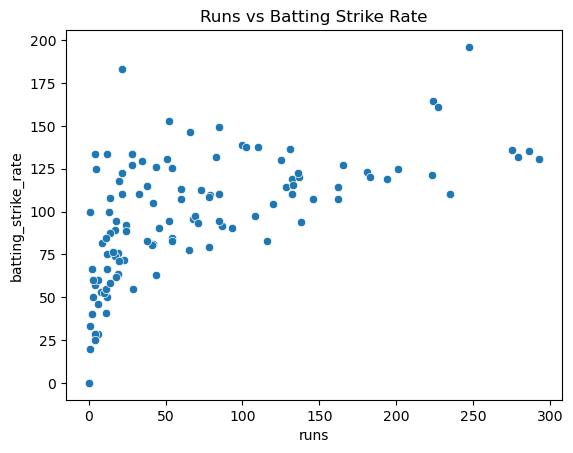

In [73]:
# Runs vs strike rate 


sns.scatterplot(x=df["runs"], y=df["batting_strike_rate"])
plt.title("Runs vs Batting Strike Rate")
plt.show()

In [74]:
#  Role Contibution Analysis 
df[["runs","wicket","catches"]].mean()

runs       35.073276
wicket      1.775862
catches     0.900862
dtype: float64

In [75]:
# saving eda graphs 
# plt.savefig("top_batters.png")

# Feature Engineering 

In [76]:
# Batting strength 
df["batting_score"]= (
    df["runs"] * 0.5 +
    df["batting_average"] * 0.3 + 
    df["batting_strike_rate"] * 0.2
)



# Bowling strength 
df["bowling_score"] = (
    df["wicket"] * 0.6 - 
    df["economy_rate"] * 0.4
)

# Feilding strength 
df["fielding_score"] = (
    df["catches"] + df["stumpings"]
)


# combines multiple stats into single meaningful metrics , makes model understand player performance better 


In [77]:
# Target Variable creation 
df["market_value"] = (
    df["batting_score"] + 
    df["bowling_score"] + 
    df["fielding_score"]
 )


# overall player value in auction 

In [78]:
# Feature and Target split   (input and output)
X = df.drop(columns = ["player", "market_value"])
y = df["market_value"]

In [79]:
# Data spliting (training data)

from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

In [80]:
# # Feature Scaling 
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train  = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # makes all features comparable

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert back
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Model Training

In [81]:
# Linear Regression 
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [82]:
from sklearn.metrics import mean_squared_error, r2_score

pred = lr.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MSE: 0.0178892819519874
R2 Score: 0.999990563217498


In [83]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [84]:
from sklearn.metrics import mean_squared_error, r2_score

pred = rf.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MSE: 76.25605794487025
R2 Score: 0.9597741354174297


In [85]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

GradientBoostingRegressor()

In [86]:
from sklearn.metrics import mean_squared_error, r2_score

pred = gb.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MSE: 42.94631552930552
R2 Score: 0.9773453713795286


<Axes: >

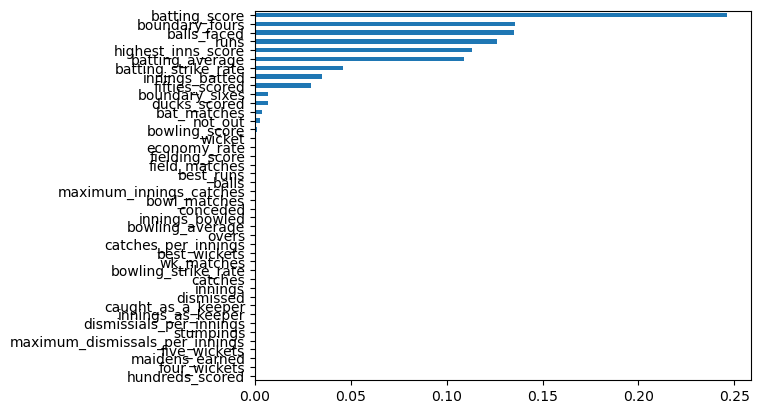

In [87]:
importance = rf.feature_importances_

import pandas as pd

feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind="barh")

In [88]:
df["predicted_value"] = rf.predict(X)

In [93]:
df["predicted_value"].describe()

count    232.000000
mean      29.123658
std       38.256861
min       -3.490040
25%        1.519240
50%        5.518800
75%       47.732925
max      146.245940
Name: predicted_value, dtype: float64

In [94]:
df["predicted_value"].head()

0     2.34908
1    14.16359
2     1.51924
3    74.21989
4     1.28848
Name: predicted_value, dtype: float64

In [ ]:
# this is auction system output 
